In [56]:
import numpy as np
import sys, os
sys.path.append('..')
import utils.io as io
import src.observables as obs
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq, fftshift, ifft

In [ ]:
filename = '../../data/iDMRG/scanChi800/Vpm_4.350_chi800.h5'
psi, metadata = io.load_mps_with_metadata(filename)

In [29]:
# O(j) = S^+_j S^-_{j+1}  ->  O^dag(i0) = S^+_{i0+1} S^-_{i0}
# op_correlation_idmrg places opAdag[0] on i0+1 and opAdag[1] on i0, so opAdag = ("Sp","Sm")
xvals = np.arange(1,201)
xvals, corr = obs.op_correlation_idmrg(psi, ("Sp","Sm"), ("Sp","Sm"), 0, xs=xvals, connected=True)


### The 2kF and 4kF pieces of $\mathcal{O} = S^+_iS^-_{i+1}$ contains luttinger liquid components coming from $\phi_c$ and $\theta_c$, and we see an overall powerlaw in this operator. 

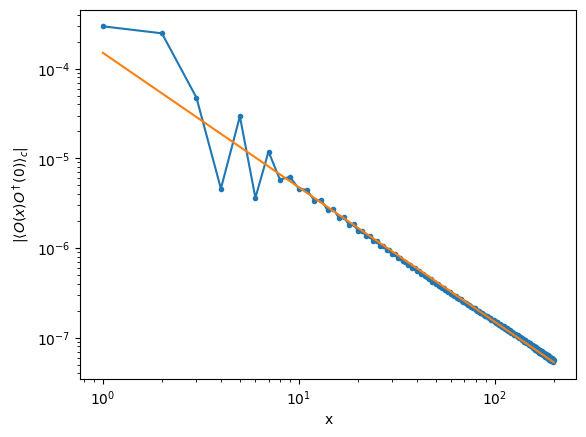

In [59]:
plt.plot(xvals, obs.denoise_rolling(np.abs(corr),1), '.-')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('x')
plt.ylabel(r'$|\langle O(x) O^\dagger(0)\rangle_c|$')
LLcomp = 0.00015*xvals**-1.5
plt.plot(xvals, LLcomp )

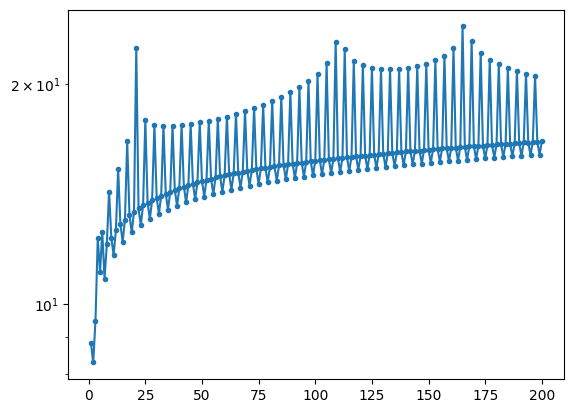

In [ ]:
suby = np.abs(np.abs(corr) - (np.cos(np.pi/2 * xvals))**3 * LLcomp)

plt.plot(xvals, -np.log(suby), '.-')
plt.yscale('log')

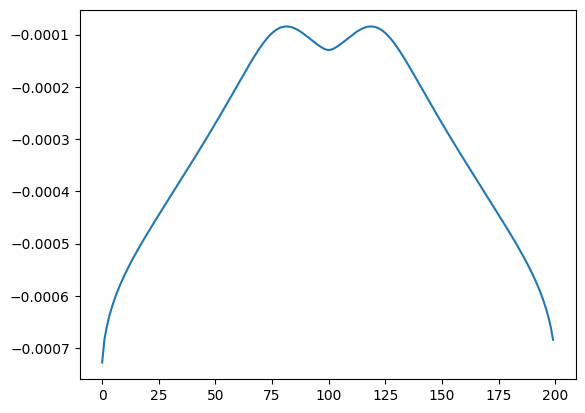

In [58]:
plt.plot(fft((corr)))